Data loaded: 40506 rows.
Tokenizing Support...
Tokenizing Attack...
Tokenizing No Relation...

Calculating Differences...


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


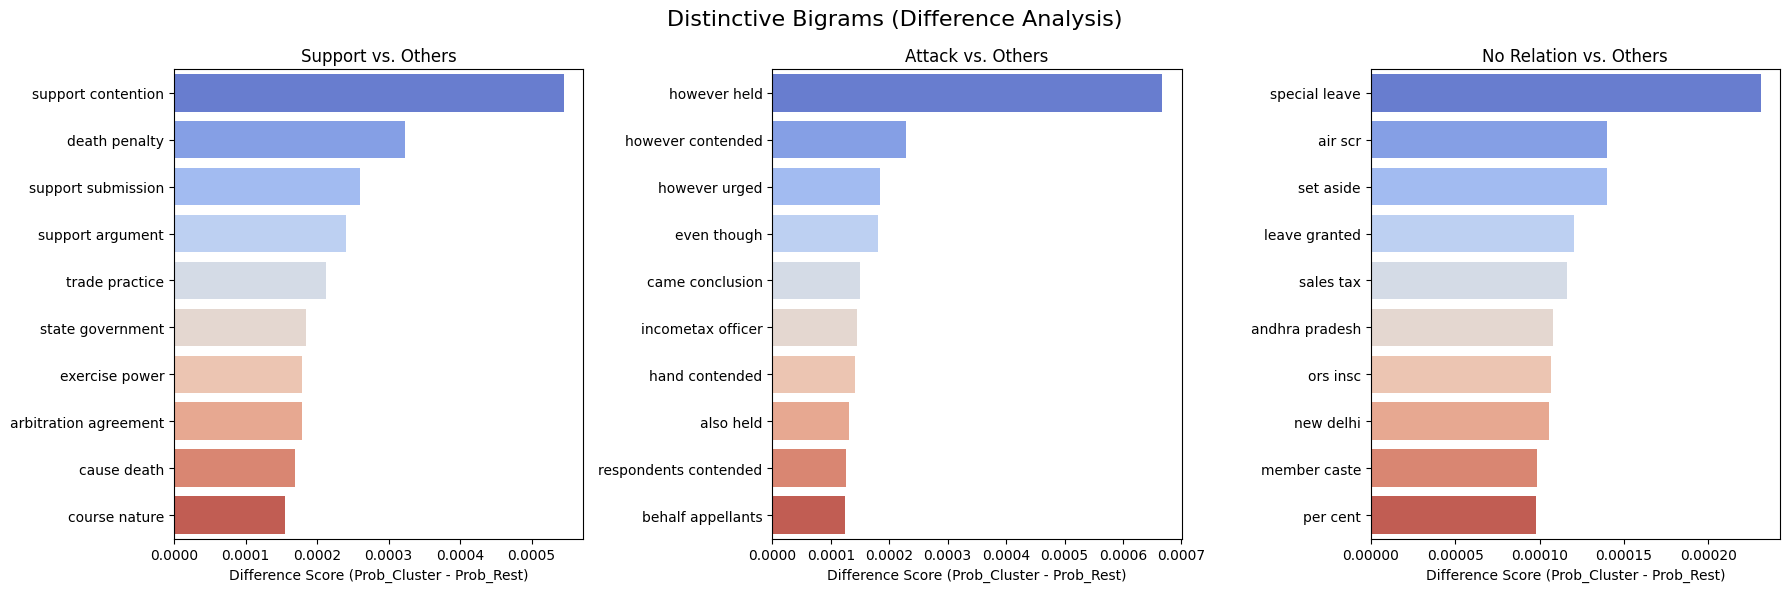

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


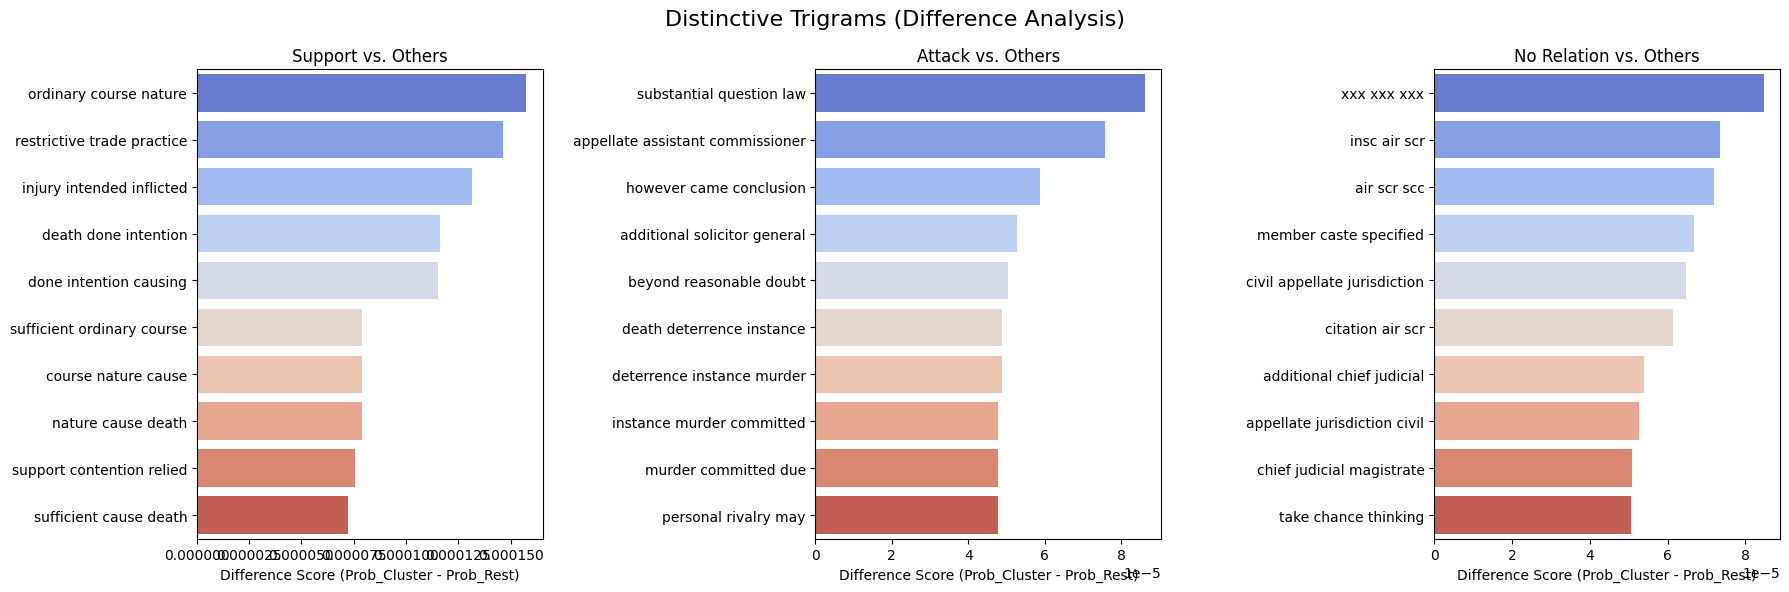

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from collections import Counter
import re
import os

# --- 1. Aggressive Legal Stopwords ---
# These are words that appear everywhere in your dataset and hide the real signal.
AGGRESSIVE_LEGAL_STOPWORDS = set([
    # Entities
    'court', 'high', 'supreme', 'tribunal', 'judge', 'bench', 'justice',
    'petitioner', 'respondent', 'appellant', 'appellee', 'plaintiff', 'defendant', 'accused',
    'counsel', 'lawyer', 'advocate', 'prosecution', 'witness', 'police',
    
    # Procedural Nouns
    'case', 'appeal', 'judgment', 'order', 'decree', 'petition', 'suit', 'trial',
    'section', 'act', 'rule', 'code', 'provision', 'article', 'clause',
    'evidence', 'record', 'fact', 'material', 'matter', 'finding', 'view',
    'file', 'application', 'issue', 'offence', 'conviction', 'sentence',
    
    # Common Modifiers/Verbs in this domain
    'learned', 'honourable', 'submitted', 'stated', 'observed', 'passed', 'appearing',
    'directed', 'impugned', 'dated', 'present', 'aforesaid', 'instant'
])

# Standard English Stopwords
try:
    from nltk.corpus import stopwords
    BASE_STOPWORDS = set(stopwords.words('english'))
except:
    # Fallback if NLTK download failed
    BASE_STOPWORDS = {'i', 'me', 'my', 'we', 'our', 'you', 'your', 'he', 'him', 'his', 'she', 'her', 'it', 'its', 'they', 'them', 'their', 'this', 'that', 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 'can', 'will', 'just', 'don', 'should', 'now'}

FULL_STOPWORDS = BASE_STOPWORDS.union(AGGRESSIVE_LEGAL_STOPWORDS)

# --- 2. Helper Functions ---

def load_and_clean_data():
    # Load your data files (Update paths if necessary)
    pos_file = "/kaggle/input/lrec-tcs-attack-support/sentencePair.txt" 
    neg_file = "/kaggle/input/lrec-tcs-attack-support/sentencePair_neg.txt"
    
    rows = []
    LABEL_MAP = {"SUPPORT": "Support", "ATTACK": "Attack", "NO_REL": "No Relation", "NO_REL\n": "No Relation"}
    
    def parse_line(line):
        parts = line.strip().split("\t")
        try:
            fname_indices = [i for i, p in enumerate(parts) if p.endswith(".txt")]
            if len(fname_indices) != 2: return None
            sent1 = " ".join(parts[fname_indices[0] + 2 : fname_indices[1]]).strip('"')
            sent2 = " ".join(parts[fname_indices[1] + 2 : len(parts) - 2]).strip('"')
            label = parts[-1]
            return {"text": sent1 + " " + sent2, "label": label} # Concatenate for simpler corpus analysis
        except: return None

    for fp in [pos_file, neg_file]:
        if os.path.exists(fp):
            with open(fp, "r", encoding="utf-8") as f:
                for line in f:
                    if p := parse_line(line): rows.append(p)
    
    df = pd.DataFrame(rows)
    if not df.empty:
        df['label'] = df['label'].str.strip().map(LABEL_MAP)
        df = df.dropna()
    return df

def get_tokens(text_list):
    all_tokens = []
    for text in text_list:
        # Clean and Tokenize
        text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
        tokens = re.findall(r'\b\w+\b', text) # Regex tokenization is faster/robust here
        # Strict Filtering
        clean = [t for t in tokens if t not in FULL_STOPWORDS and len(t) > 2]
        all_tokens.extend(clean)
    return all_tokens

# --- 3. The "Keyness" / Difference Algorithm ---

def calculate_difference_scores(target_tokens, reference_tokens, ngram_n=1):
    """
    Calculates: (Freq in Target) - (Freq in Reference)
    High Positive Score = Unique to Target
    High Negative Score = Unique to Reference
    """
    # 1. Generate N-grams
    target_ngrams = list(ngrams(target_tokens, ngram_n))
    ref_ngrams = list(ngrams(reference_tokens, ngram_n))
    
    # 2. Count
    target_counts = Counter(target_ngrams)
    ref_counts = Counter(ref_ngrams)
    
    # 3. Normalize (Convert to Probabilities)
    total_target = sum(target_counts.values())
    total_ref = sum(ref_counts.values())
    
    if total_target == 0 or total_ref == 0: return []

    scores = {}
    # We look at all ngrams present in the target
    for item, count in target_counts.items():
        # Minimum frequency threshold to avoid noise (e.g., must appear 5+ times)
        if count < 5: continue 
        
        prob_target = count / total_target
        prob_ref = ref_counts[item] / total_ref
        
        # Difference Score
        scores[item] = prob_target - prob_ref
        
    # Sort by highest difference
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return sorted_scores[:10] # Top 10

# --- 4. Plotting ---

def plot_differences(results_dict, title_suffix):
    num_plots = len(results_dict)
    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 6))
    fig.suptitle(f'Distinctive {title_suffix} (Difference Analysis)', fontsize=16)
    
    if num_plots == 1: axes = [axes]
    
    for i, (cluster, items) in enumerate(results_dict.items()):
        if not items: continue
        labels, values = zip(*items)
        # Clean labels
        labels = [" ".join(l) if isinstance(l, tuple) else l for l in labels]
        
        # Use diverging palette (Cool/Warm) to emphasize "Difference"
        sns.barplot(x=list(values), y=list(labels), ax=axes[i], palette='coolwarm')
        axes[i].set_title(f'{cluster} vs. Others')
        axes[i].set_xlabel('Difference Score (Prob_Cluster - Prob_Rest)')
        
    plt.tight_layout()
    plt.show()

# --- Main Execution ---

if __name__ == "__main__":
    df = load_and_clean_data()
    
    if not df.empty:
        print(f"Data loaded: {len(df)} rows.")
        relations = df['label'].unique()
        
        # 1. Prepare Token Pools
        # We need a pool for "Everything" to calculate the "Rest"
        cluster_tokens = {}
        for r in relations:
            print(f"Tokenizing {r}...")
            # Sample to speed up if dataset is huge
            texts = df[df['label'] == r]['text'].tolist()
            cluster_tokens[r] = get_tokens(texts)

        # 2. Analyze Differences
        print("\nCalculating Differences...")
        
        # Store results
        diff_bigrams = {}
        diff_trigrams = {}
        diff_verbs = {} # We can reuse unigram logic for verbs if we had POS tags, 
                        # but here we'll stick to ngrams for reliability in this env.
        
        for r in relations:
            # Target = This Cluster
            target = cluster_tokens[r]
            
            # Reference = All OTHER Clusters combined
            reference = []
            for other_r in relations:
                if other_r != r:
                    reference.extend(cluster_tokens[other_r])
            
            # Get Scores
            diff_bigrams[r] = calculate_difference_scores(target, reference, ngram_n=2)
            diff_trigrams[r] = calculate_difference_scores(target, reference, ngram_n=3)
            
        # 3. Visualizations
        plot_differences(diff_bigrams, "Bigrams")
        plot_differences(diff_trigrams, "Trigrams")
        
    else:
        print("Error: No data found. Please check file names.")